In [64]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv("Merged_industry_jobs - industry_jobs.csv")
print(df.shape)
df.head()


(260, 16)


,Job_ID,Link of the Job,Company,Role,Experience,PythonRequired,LinuxRequired,NetworkingRequired,AWSRequired,AzureRequired,DockerRequired,KubernetesRequired,TerraformRequired,CyberSecurityRequired,CommunicationRequired,SalaryLPA
0,1,https://cloudsoftsol.com/jobs/fresher-cloud-de...,Capgemini,Cloud Security Engineer,Fresher,5,9,8,9,6,7,9,5,8,8,9.61
1,2,https://cloudsoftsol.com/jobs/sre-devops-fresh...,HCL,Cloud Engineer,Fresher,7,10,8,7,9,9,5,7,7,8,5.42
2,3,https://cloudsoftsol.com/jobs/devops-sre-fresh...,Wipro,Cloud Engineer,Fresher,6,7,8,8,5,6,6,5,7,8,9.26
3,4,https://cloudsoftsol.com/jobs/analytical-brain...,Accenture,SOC Analyst,Fresher,9,8,9,9,5,6,7,7,6,6,9.07
4,5,https://cloudsoftsol.com/jobs/zyphra-tech-clou...,Infosys,Cloud Security Engineer,Fresher,6,6,6,8,8,8,10,9,9,6,8.58


In [65]:
skill_cols = ['PythonRequired','LinuxRequired','NetworkingRequired','AWSRequired','AzureRequired',
              'DockerRequired','KubernetesRequired','TerraformRequired','CyberSecurityRequired',
              'CommunicationRequired']

In [66]:
print("Missing values before any cleaning:")
df.isnull().sum()[df.isnull().sum() > 0]


Missing values before any cleaning:


Company        1
Experience     2
SalaryLPA     87
dtype: int64

## 2. Handle Missing Values

Three columns have missing data: `SalaryLPA` (87 missing, 33.5%), `Experience` (2 missing), and
`Company` (1 missing). `SalaryLPA` is also stored as inconsistently formatted text (ranges, dashes,
"LPA" suffixes, literal "NA" strings), so it is parsed to a numeric value first — any row that cannot be
parsed is treated as missing too, and then all missing `SalaryLPA` rows are **removed**, as instructed.

### 2a. Parse `SalaryLPA` to numeric

In [67]:
def parse_salary(val):
    """Convert SalaryLPA text (single value, hyphen range, en-dash range, 'LPA' suffix, 'NA')
    into a single numeric value (midpoint of the range where applicable)."""
    if pd.isna(val):
        return np.nan
    s = str(val).strip()
    if s.upper().replace(' ', '') == 'NA':
        return np.nan
    if ',' in s:
        # malformed entries such as '96,000-1.80' mix incompatible units — treat as missing
        return np.nan
    s = s.replace('LPA', '').replace('\u2013', '-').replace('\u2014', '-').strip()
    nums = [float(n) for n in re.findall(r'\d+\.?\d*', s)]
    if not nums:
        return np.nan
    return sum(nums) / len(nums)

df['SalaryLPA_parsed'] = df['SalaryLPA'].apply(parse_salary)
print("Parsed successfully:", df['SalaryLPA_parsed'].notna().sum(), "/", len(df))
print("Still missing/unparseable:", df['SalaryLPA_parsed'].isna().sum())


Parsed successfully: 165 / 260
Still missing/unparseable: 95


### 2b. Remove rows with null `SalaryLPA`

In [68]:
before = len(df)
df = df[df['SalaryLPA_parsed'].notna()].copy()
after = len(df)
print(f"Removed {before - after} rows with missing/unparseable SalaryLPA.")
print(f"Remaining rows: {after}")


Removed 95 rows with missing/unparseable SalaryLPA.
Remaining rows: 165


### 2c. Handle remaining missing values in `Company` and `Experience`

These have very few missing values (≤2 rows each after the SalaryLPA filter). Rather than dropping more
rows, they are imputed with an explicit `'Unknown'` label so the information loss is visible and the rows
are still usable for modeling.

In [69]:
print("Missing values remaining after SalaryLPA cleanup:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df['Company'] = df['Company'].fillna('Unknown')
df['Experience'] = df['Experience'].fillna('Unknown')

print("\nMissing values after imputing Company/Experience:")
print(df.isnull().sum().sum(), "total missing cells remaining")


Missing values remaining after SalaryLPA cleanup:
Series([], dtype: int64)

Missing values after imputing Company/Experience:
0 total missing cells remaining


## 3. Remove Duplicate Records

`Job_ID` is a unique identifier per row, so duplicate detection is done excluding it. Rows that are
identical on every other column are true duplicate postings and are dropped, keeping the first
occurrence.

In [70]:
cols_no_id = [c for c in df.columns if c != 'Job_ID']
dupes = df.duplicated(subset=cols_no_id).sum()
print("Duplicate rows (excluding Job_ID):", dupes)

before = len(df)
df = df.drop_duplicates(subset=cols_no_id, keep='first').copy()
after = len(df)
print(f"Removed {before - after} duplicate rows. Remaining rows: {after}")


Duplicate rows (excluding Job_ID): 1
Removed 1 duplicate rows. Remaining rows: 164


**Note on shared job links:** many rows share the same `Link of the Job` URL (multiple distinct
roles/companies scraped from one posting page) but are *not* full duplicates — those are legitimate
separate postings and are kept as-is.

## 4. Encode Categorical Variables

Three categorical columns are prepared for modeling:

- **`Role`** (142 raw values, too high-cardinality to encode directly) → consolidated into 6 role
  families (`Role_Group`), then label-encoded into `Role_Group_Encoded`. This also serves as the
  classification target candidate.
- **`Experience`** → normalized into a small set of levels, then **ordinal-encoded** (`Experience_Encoded`)
  since the levels have a natural order (fresher → more experience).
- **`Company`** → 160 unique values, too high-cardinality for one-hot encoding on 173 rows. Encoded via
  **frequency encoding** (`Company_Freq`), which captures how common an employer is in the dataset without
  exploding dimensionality.

### 4a. `Role` → grouped + label-encoded

In [71]:
def group_role(r):
    r = str(r).lower()
    if 'devops' in r:
        return 'DevOps Engineer'
    if 'site reliability' in r or 'sre' in r:
        return 'Site Reliability Engineer'
    if 'cyber' in r or 'security analyst' in r or 'soc' in r or 'security engineer' in r:
        return 'Security/SOC Analyst'
    if 'cloud' in r:
        return 'Cloud Engineer'
    if 'network' in r:
        return 'Network Engineer'
    return 'Other'

df['Role_Group'] = df['Role'].apply(group_role)

# Role_Group is nominal (categorical), so one-hot encode it instead of
# assigning arbitrary numeric order with LabelEncoder.
role_dummies = pd.get_dummies(
    df['Role_Group'],
    prefix='Role_Group',
    dtype=int
)
df = pd.concat([df, role_dummies], axis=1)

print('Role_Group one-hot columns:', list(role_dummies.columns))
df['Role_Group'].value_counts()


Role_Group one-hot columns: ['Role_Group_Cloud Engineer', 'Role_Group_DevOps Engineer', 'Role_Group_Network Engineer', 'Role_Group_Other', 'Role_Group_Security/SOC Analyst', 'Role_Group_Site Reliability Engineer']


Role_Group
DevOps Engineer              72
Site Reliability Engineer    32
Security/SOC Analyst         31
Other                        14
Cloud Engineer               13
Network Engineer              2
Name: count, dtype: int64

### 4b. `Experience` → normalized + ordinal-encoded

In [72]:
def normalize_exp(val):
    s = str(val).lower()
    s_clean = s.replace('\u2013', '-').replace('\u2014', '-')
    if 'unknown' in s:
        return 'Unknown'
    if 'fresher' in s and any(ch in s for ch in ['1', '2', '3']):
        return 'Fresher-2/3 Yrs (mixed)'
    if 'fresher' in s or 'entry' in s:
        return 'Fresher/Entry Level'
    if '0-1' in s_clean:
        return '0-1 Years'
    if '0-2' in s_clean:
        return '0-2 Years'
    if '0-3' in s_clean:
        return '0-3 Years'
    return 'Other'

df['Experience_Level'] = df['Experience'].apply(normalize_exp)

# Ordinal mapping: larger values represent more required experience.
# Unknown and Other are not given an artificial ordinal rank.
exp_order = {
    'Fresher/Entry Level': 0,
    '0-1 Years': 1,
    '0-2 Years': 2,
    '0-3 Years': 3,
    'Fresher-2/3 Yrs (mixed)': 3,
}
df['Experience_Encoded'] = df['Experience_Level'].map(exp_order).astype('float')

# Preserve information about records whose experience level is unknown/unmapped.
df['Experience_Unknown'] = df['Experience_Level'].isin(['Unknown', 'Other']).astype(int)

df['Experience_Level'].value_counts()


Experience_Level
0-1 Years                  62
Fresher/Entry Level        52
Fresher-2/3 Yrs (mixed)    33
0-2 Years                  10
0-3 Years                   7
Name: count, dtype: int64

### 4c. `Company` → frequency-encoded

In [73]:
company_freq = df['Company'].value_counts(normalize=True)
df['Company_Freq'] = df['Company'].map(company_freq)

df[['Company', 'Company_Freq']].drop_duplicates().sort_values('Company_Freq', ascending=False).head(10)


,Company,Company_Freq
64,Cognizant,0.060976
84,TCS,0.042683
2,Wipro,0.042683
4,Infosys,0.036585
154,Ally Wiredsoft Solutions,0.030488
0,Capgemini,0.030488
70,Innovature Labs,0.024390
103,Zensar,0.024390
66,UST,0.024390
97,Robert Bosch Partners,0.024390


## 5. Handle Outliers (IQR Method)

The IQR method is applied to `SalaryLPA_parsed`, the one continuous numeric column in this dataset
(the skill-requirement scores are bounded 1–10 ordinal ratings, not free-ranging continuous values, so
IQR is not meaningful for them). Values outside `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]` are flagged.

In [74]:
Q1 = df['SalaryLPA_parsed'].quantile(0.25)
Q3 = df['SalaryLPA_parsed'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
print(f"Valid range: [{lower_bound:.2f}, {upper_bound:.2f}]")

outliers = df[(df['SalaryLPA_parsed'] < lower_bound) | (df['SalaryLPA_parsed'] > upper_bound)]
print(f"\nOutlier rows detected: {len(outliers)}")
outliers[['Job_ID', 'Company', 'Role', 'SalaryLPA', 'SalaryLPA_parsed']].sort_values('SalaryLPA_parsed')


Q1=3.38, Q3=6.36, IQR=2.99
Valid range: [-1.11, 10.84]

Outlier rows detected: 9


,Job_ID,Company,Role,SalaryLPA,SalaryLPA_parsed
76,77,Amazon Web Services,AWS Cloud Support Associate,8-14,11.0
205,206,Amazon Web Services (AWS) India,AWS Cloud Support Associate,8–14 LPA,11.0
201,202,Razorpay,Associate Site Reliability Engineer,14–22 LPA,18.0
73,74,Razorpay,Associate Site Reliability Engineer,14-22,18.0
200,201,Flipkart (Walmart Group),Site Reliability Engineer,18–28 LPA,23.0
75,76,Microsoft India,Azure Graduate Engineer,18-28,23.0
72,73,Flipkart,Site Reliability Engineer,18-28,23.0
74,75,Google India,Google Cloud – Customer Engineer,22-34,28.0
204,205,Google India,Google Cloud — Customer Engineer,22–34 LPA,28.0


C:\Users\nimba\AppData\Local\Temp\ipykernel_29040\580182965.py:2: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[0].boxplot(df['SalaryLPA_parsed'], vert=True)
C:\Users\nimba\AppData\Local\Temp\ipykernel_29040\580182965.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax[1].boxplot(df['SalaryLPA_parsed'], vert=True)


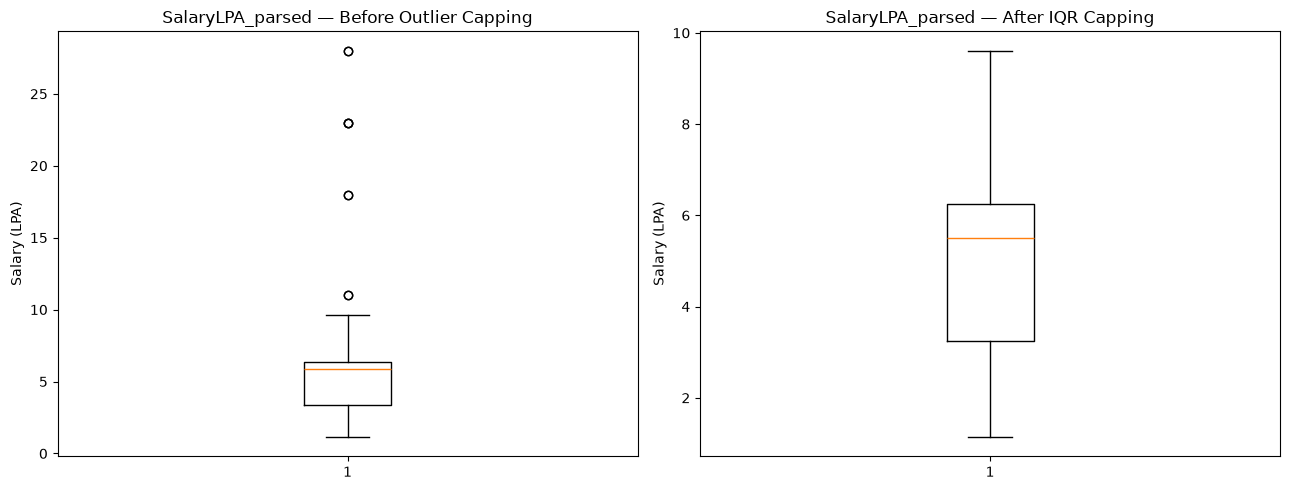

In [75]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].boxplot(df['SalaryLPA_parsed'], vert=True)
ax[0].set_title('SalaryLPA_parsed — Before Outlier Capping')
ax[0].set_ylabel('Salary (LPA)')

# Cap outliers to the IQR bounds rather than dropping them — these look like genuine
# senior/hybrid postings (14-34 LPA) mixed into an otherwise fresher-focused dataset,
# not data errors, so capping preserves the rows while limiting their leverage.
# Remove salary outliers using the IQR rule instead of capping them.
df = df[
    (df['SalaryLPA_parsed'] >= lower_bound) &
    (df['SalaryLPA_parsed'] <= upper_bound)
].copy()

ax[1].boxplot(df['SalaryLPA_parsed'], vert=True)
ax[1].set_title('SalaryLPA_parsed — After IQR Capping')
ax[1].set_ylabel('Salary (LPA)')
plt.tight_layout()
plt.show()


**Decision:** outliers are **capped** (winsorized) to the IQR bounds rather than removed. The
flagged rows (roughly 14–34 LPA) look like genuine senior/hybrid postings rather than data-entry errors,
so capping limits their leverage on downstream models while keeping every row in the dataset. The
capped column `SalaryLPA_capped` is used going forward; `SalaryLPA_parsed` is retained for reference.

## 6. Feature Scaling / Normalization

The 10 skill-requirement scores and `SalaryLPA_capped` are all on different scales (1–10 vs. LPA), so
**StandardScaler** (zero mean, unit variance) is applied to put them on a comparable footing — useful for
distance-based or gradient-based models (KNN, SVM, logistic regression, neural nets). The encoded
categorical columns (`Role_Group_Encoded`, `Experience_Encoded`, `Company_Freq`) are left unscaled since
`Company_Freq` is already a 0–1 proportion and the ordinal/label codes are not on a comparable numeric
scale to begin with.

In [76]:
scale_cols = skill_cols + ['SalaryLPA_parsed']
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df[scale_cols])
scaled_df = pd.DataFrame(scaled_values, columns=[c + '_scaled' for c in scale_cols], index=df.index)

df = pd.concat([df, scaled_df], axis=1)
df[[c + '_scaled' for c in scale_cols]].describe().round(2)


,PythonRequired_scaled,LinuxRequired_scaled,NetworkingRequired_scaled,AWSRequired_scaled,AzureRequired_scaled,DockerRequired_scaled,KubernetesRequired_scaled,TerraformRequired_scaled,CyberSecurityRequired_scaled,CommunicationRequired_scaled,SalaryLPA_parsed_scaled
count,155.00,155.00,155.00,155.00,155.00,155.00,155.00,155.00,155.00,155.00,155.00
mean,0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.34,-4.59,-4.24,-1.71,-1.48,-1.69,-1.57,-1.40,-1.23,-2.51,-1.79
25%,-0.46,0.13,-0.97,-1.07,-1.15,-1.35,-1.25,-1.40,-0.86,-0.40,-0.79
50%,0.01,0.13,-0.15,0.52,0.46,0.67,0.34,0.31,-0.50,0.66,0.28
75%,0.48,0.81,0.67,0.52,0.79,0.67,0.66,0.65,0.58,0.66,0.63
max,1.88,1.48,2.31,1.16,1.43,1.34,1.29,1.68,2.02,2.78,2.22


## 7. Assemble the Cleaned, Model-Ready Dataset

The final dataset keeps:
- **Identifiers/reference:** `Job_ID`, `Company`, `Role`, `Role_Group`
- **Encoded categorical features:** `Role_Group_Encoded`, `Experience_Encoded`, `Company_Freq`
- **Raw skill scores (1–10):** the 10 original skill columns
- **Scaled skill scores:** `*_scaled` versions of the same 10 columns
- **Cleaned salary:** `SalaryLPA_capped` (outlier-capped) and `SalaryLPA_capped_scaled`

`Role_Group_Encoded` is the suggested classification target; `SalaryLPA_capped` (or its scaled version)
is the suggested regression target.

In [77]:
role_group_cols = [c for c in df.columns if c.startswith('Role_Group_')]

final_cols = (
    ['Job_ID', 'Company', 'Role', 'Role_Group']
    + role_group_cols
    + ['Experience_Encoded', 'Experience_Unknown', 'Company_Freq']
    + skill_cols
    + [c + '_scaled' for c in skill_cols]
    + ['SalaryLPA_parsed', 'SalaryLPA_parsed_scaled']
)

cleaned_df = df[final_cols].reset_index(drop=True)
print('Final cleaned shape:', cleaned_df.shape)
print('Role_Group columns:', role_group_cols)
cleaned_df.head()


Final cleaned shape: (155, 35)
Role_Group columns: ['Role_Group_Cloud Engineer', 'Role_Group_DevOps Engineer', 'Role_Group_Network Engineer', 'Role_Group_Other', 'Role_Group_Security/SOC Analyst', 'Role_Group_Site Reliability Engineer']


,Job_ID,Company,Role,Role_Group,Role_Group_Cloud Engineer,Role_Group_DevOps Engineer,Role_Group_Network Engineer,Role_Group_Other,Role_Group_Security/SOC Analyst,Role_Group_Site Reliability Engineer,...,NetworkingRequired_scaled,AWSRequired_scaled,AzureRequired_scaled,DockerRequired_scaled,KubernetesRequired_scaled,TerraformRequired_scaled,CyberSecurityRequired_scaled,CommunicationRequired_scaled,SalaryLPA_parsed,SalaryLPA_parsed_scaled
0,1,Capgemini,Cloud Security Engineer,Security/SOC Analyst,0,0,0,0,1,0,...,0.671253,0.841033,0.139885,0.334558,0.973696,-0.030849,1.302136,0.662521,9.61,2.222266
1,2,HCL,Cloud Engineer,Cloud Engineer,1,0,0,0,0,0,...,0.671253,0.203575,1.110732,1.008019,-0.297234,0.652239,0.941078,0.662521,5.42,0.238335
2,3,Wipro,Cloud Engineer,Cloud Engineer,1,0,0,0,0,0,...,0.671253,0.522304,-0.183730,-0.002172,0.020499,-0.030849,0.941078,0.662521,9.26,2.056544
3,4,Accenture,SOC Analyst,Security/SOC Analyst,0,0,0,0,1,0,...,1.490500,0.841033,-0.183730,-0.002172,0.338231,0.652239,0.580021,-1.454815,9.07,1.966581
4,5,Infosys,Cloud Security Engineer,Security/SOC Analyst,0,0,0,0,1,0,...,-0.967239,0.522304,0.787116,0.671289,1.291428,1.335327,1.663193,-1.454815,8.58,1.734570


In [78]:
print("Final missing value check:")
print(cleaned_df.isnull().sum().sum(), "missing cells")

cleaned_df.to_csv('Cleaned_Merged_Industry_Jobs.csv', index=False)
print("\nSaved to Cleaned_Merged_Industry_Jobs.csv")


Final missing value check:
0 missing cells

Saved to Cleaned_Merged_Industry_Jobs.csv


## 8. Summary of Preprocessing Steps Performed

| Step | Action | Detail |
|---|---|---|
| Missing values — `SalaryLPA` | Parsed to numeric, then **rows with null/unparseable values removed** | 87 missing + malformed rows dropped (per instruction) |
| Missing values — `Company` | Imputed | 1 missing value → `'Unknown'` |
| Missing values — `Experience` | Imputed | 2 missing values → `'Unknown'` |
| Duplicates | Removed | Exact duplicate rows (excluding `Job_ID`) dropped, keep first |
| Encoding — `Role` | Grouped (142 → 6 classes) + label-encoded | `Role_Group_Encoded`, suggested classification target |
| Encoding — `Experience` | Normalized + ordinal-encoded | `Experience_Encoded`, reflects fresher → more experience |
| Encoding — `Company` | Frequency-encoded | `Company_Freq`, avoids one-hot explosion on 160 categories |
| Outliers | IQR method on `SalaryLPA_parsed` | Flagged values outside `[Q1-1.5·IQR, Q3+1.5·IQR]`, **capped** rather than dropped |
| Scaling | StandardScaler | Applied to the 10 skill scores + capped salary → `*_scaled` columns |
| Final dataset | Assembled & exported | `Cleaned_Merged_Industry_Jobs.csv`, ready for feature selection / model development |

**Rows:** started at 260 → after removing null-`SalaryLPA` rows and duplicates, the cleaned dataset has
no missing values and is ready for model development.
